# Taller Práctico: Algoritmos Genéticos y Optimización
**Cátedra de Inteligencia Artificial - Ingeniería (IA-2026)**  
*CUADERNO DE TRABAJO (ESTUDIANTES) - Duración estimada: 90 a 120 minutos*

---

### Estructura y Sistema de Calificación
- **Bloque Obligatorio (2.0 puntos base):**
  - **Fase 1 (0.8 pts):** Algoritmo Genético Canónico artesanal en 5 bits (`TODO 1`, `TODO 2`, `TODO 3`).
  - **Fase 2 (0.6 pts):** Smart Rockets — Rescate en el cinturón de asteroides con física 2D (`TODO 4`).
  - **Fase 3 (0.6 pts):** TSP — La ruta del repartidor en Mar del Plata con operadores de permutación (`TODO 5`).
- **Misión Especial / Bonus Track (+0.5 puntos extra):**
  - **Fase 4 (+0.5 pts):** Criptoanálisis de sustitución — Descifrar un mensaje interceptado secreto (`TODO 6`).
  - *Nota máxima posible: 2.5 puntos.*

---
### Metodología de Trabajo y Evaluación
Cada bloque cuenta con celdas de **autoevaluación automática** (`assert`). Al finalizar, valida tu cuaderno ejecutando en tu terminal:
```bash
py test/test_taller_genetico.py
```
La suite otorgará tu puntaje base (hasta 2.0 pts) y registrará si completaste el bonus track (+0.5 pts). Cuando abras tu **Pull Request (PR)**, GitHub Actions ejecutará esta misma verificación.

In [818]:
# Instalacion condicional para Google Colab o entornos sin PyGAD instalado
try:
    import pygad
except ImportError:
    %pip install -q pygad
    import pygad

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, HTML
import string
import re

# Estilo visual limpio y legible para graficos cientificos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## FASE 1: Algoritmo Genético Canónico desde Cero [OBLIGATORIA - 0.8 pts]
*(Basado en el Problema 1 de la guía y diapositiva 27 de la teoría)*

Queremos encontrar el máximo de la función cuadrática:
$$f(x) = 300 - (x - 15)^2$$
en el dominio discreto $x \in \{0, 1, 2, \dots, 31\}$.

### Representación Cromosómica
Como el espacio tiene $32 = 2^5$ estados posibles, cada individuo será una cadena binaria (cromosoma) de **longitud $L = 5$ bits**:
$$c = [b_4, b_3, b_2, b_1, b_0], \quad b_i \in \{0, 1\}$$
donde $b_4$ es el bit más significativo (MSB) y $b_0$ el menos significativo (LSB):
$$x = \sum_{i=0}^4 b_i \cdot 2^{4-i}$$

**Ejemplos:**
- `[0, 0, 0, 0, 0]` $\implies x = 0$
- `[0, 1, 1, 1, 1]` $\implies x = 15$ *(máximo teórico esperado)*
- `[1, 1, 1, 1, 1]` $\implies x = 31$

In [819]:
# ==========================================================================
# [TODO 1] Decodificacion Binaria y Evaluacion de Aptitud (Fitness) [0.3 pts]
# ==========================================================================

def decodificar_cromosoma(cromosoma):
    """
    TODO 1.A: Convierte un vector binario de 5 bits (ej: np.array([0, 1, 1, 1, 1]))
    a su valor entero equivalente x en el intervalo [0, 31].
    
    Parametros:
      cromosoma: array 1D de ceros y unos de longitud 5.
    Retorna:
      Entero x entre 0 y 31.
    """
    # ----------------------------------------------------------------------
    # Pista 1: Recuerda la ponderacion por potencias de 2: [16, 8, 4, 2, 1].
    # Pista 2: Puedes usar producto escalar: np.dot(cromosoma, [16, 8, 4, 2, 1])
    aux=cromosoma.copy()
    aux=aux[::-1]
    cal=sum(b*(2**i) for i,b in enumerate(aux))
    return cal
    # ----------------------------------------------------------------------

def calcular_fitness(x):
    """
    TODO 1.B: Evalua la funcion objetivo f(x) = 300 - (x - 15)^2.
    
    Parametros:
      x: valor entero o float.
    Retorna:
      Valor de fitness (escalar positivo).
    """
    # ----------------------------------------------------------------------
    # Pista: En el vertice x = 15, el valor debe ser exactamente 300.

    return 300-(x-15)**2
    # ----------------------------------------------------------------------


In [820]:
# TEST AUTOMATICO - TODO 1
c_cero = np.array([0, 0, 0, 0, 0])
c_max = np.array([0, 1, 1, 1, 1])
c_fin = np.array([1, 1, 1, 1, 1])

assert decodificar_cromosoma(c_cero) == 0, f"[ERROR] [0,0,0,0,0] debe dar 0, dio {decodificar_cromosoma(c_cero)}"
assert decodificar_cromosoma(c_max) == 15, f"[ERROR] [0,1,1,1,1] debe dar 15, dio {decodificar_cromosoma(c_max)}"
assert decodificar_cromosoma(c_fin) == 31, f"[ERROR] [1,1,1,1,1] debe dar 31, dio {decodificar_cromosoma(c_fin)}"

assert calcular_fitness(15) == 300, f"[ERROR] Fitness en x=15 debe dar 300, dio {calcular_fitness(15)}"
assert calcular_fitness(0) == 75, f"[ERROR] Fitness en x=0 debe dar 75, dio {calcular_fitness(0)}"
assert calcular_fitness(31) == 44, f"[ERROR] Fitness en x=31 debe dar 44, dio {calcular_fitness(31)}"
print("[OK] Felicitaciones: TODO 1 aprobado con exito. Decodificacion y Fitness correctos.")

[OK] Felicitaciones: TODO 1 aprobado con exito. Decodificacion y Fitness correctos.


### 1.2 Operadores de Selección y Cruzamiento

#### A) Selección por Ruleta Proporcional (Roulette Wheel Selection)
Cada individuo $i$ tiene una probabilidad de reproducción proporcional a su aptitud:
$$p_i = \frac{f_i}{\sum_{k=1}^N f_k}$$
Los individuos más aptos ocupan una porción mayor de la ruleta, favoreciendo su selección sin excluir completamente a los menos aptos (preservando diversidad).

#### B) Cruzamiento en Un Punto (Single-Point Crossover)
Dados dos padres $P_1$ y $P_2$, se elige aleatoriamente un punto de corte $k \in \{1, 2, \dots, L-1\}$:
- $\text{Hijo}_1 = P_1[:k] + P_2[k:]$
- $\text{Hijo}_2 = P_2[:k] + P_1[k:]$

In [821]:
# ==========================================================================
# [TODO 2] Seleccion por Ruleta y Cruzamiento en Un Punto [0.3 pts]
# ==========================================================================

def seleccion_ruleta(poblacion, fitness_vals, n_padres):
    """
    TODO 2.A: Selecciona n_padres de la poblacion segun su probabilidad de ruleta p_i = f_i / sum(f_k).
    
    Parametros:
      poblacion: array 2D de forma (N, L) con los cromosomas.
      fitness_vals: array 1D de longitud N con las aptitudes.
      n_padres: cantidad de individuos a seleccionar.
    Retorna:
      array 2D de forma (n_padres, L) con los padres seleccionados.
    """
    # ----------------------------------------------------------------------
    # Pista 1: Normaliza el fitness para obtener las probabilidades: probs = fitness_vals / np.sum(fitness_vals)
    # Pista 2: Utiliza np.random.choice(len(poblacion), size=n_padres, replace=True, p=probs)
    proba=fitness_vals/np.sum(fitness_vals) #array de aptitudes normalizadas
    idxs=np.random.choice(len(poblacion),size=n_padres, replace=True,p=proba)
    return poblacion[idxs]
    # ----------------------------------------------------------------------

def crossover_un_punto(padre1, padre2, punto_corte):
    """
    TODO 2.B: Cruza dos cromosomas en un punto de corte k (1 <= k < L).
    
    Parametros:
      padre1, padre2: arrays 1D con los cromosomas de los padres.
      punto_corte: indice entero donde se divide la cadena.
    Retorna:
      Tupla (hijo1, hijo2) con los dos nuevos cromosomas.
    """
    # ----------------------------------------------------------------------
    # Pista: hijo1 une padre1[:punto_corte] con padre2[punto_corte:], hijo2 la combinacion opuesta.
    hi1=np.concatenate([padre1[:punto_corte],padre2[punto_corte:]])
    hi2=np.concatenate([padre2[:punto_corte],padre1[punto_corte:]])
    return hi1,hi2
    # ----------------------------------------------------------------------


In [822]:
# TEST AUTOMATICO - TODO 2
pob_test = np.array([
    [0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 1, 1]
])
fit_test = np.array([75.0, 44.0, 300.0])

padres_sel = seleccion_ruleta(pob_test, fit_test, n_padres=4)
assert padres_sel is not None, "[ERROR] seleccion_ruleta retorno None."
assert len(padres_sel) == 4, f"[ERROR] Se esperaban 4 padres, dio {len(padres_sel)}"

p1 = np.array([0, 0, 0, 0, 0])
p2 = np.array([1, 1, 1, 1, 1])
h1, h2 = crossover_un_punto(p1, p2, punto_corte=2)

assert h1 is not None and h2 is not None, "[ERROR] crossover_un_punto retorno None."
assert np.array_equal(h1, [0, 0, 1, 1, 1]), f"[ERROR] hijo1 con corte=2 incorrecto: {h1}"
assert np.array_equal(h2, [1, 1, 0, 0, 0]), f"[ERROR] hijo2 con corte=2 incorrecto: {h2}"
print("[OK] Felicitaciones: TODO 2 aprobado con exito. Ruleta y Cruzamiento validados.")

[OK] Felicitaciones: TODO 2 aprobado con exito. Ruleta y Cruzamiento validados.


### 1.3 Operadores de Mutación y Reemplazo con Elitismo

#### A) Mutación Puntual (Bit-Flip)
Cada gen (bit) del cromosoma tiene una pequeña probabilidad $p_m$ (por ejemplo, $0.05$) de invertirse ($0 \to 1$ o $1 \to 0$).
Este operador introduce **exploración** en el espacio de búsqueda y evita la convergencia prematura a óptimos locales.

#### B) Elitismo (Preservación de las Mejores Soluciones)
El operador de cruce y mutación puede destruir accidentalmente al mejor individuo de la población.
El **elitismo** garantiza que los $K$ mejores individuos (por ejemplo, $K=2$) pasen **directamente e intactos** a la siguiente generación.

In [823]:
# ==========================================================================
# [TODO 3] Mutacion Puntual y Ciclo Generacional con Elitismo [0.2 pts]
# ==========================================================================

def mutacion_puntual(cromosoma, prob_mutacion=0.05):
    """
    TODO 3.A: Itera sobre cada gen del cromosoma e invierte su valor (0 a 1, 1 a 0)
    si un numero aleatorio uniforme en [0, 1) es menor que prob_mutacion.
    
    Parametros:
      cromosoma: array 1D con la cadena de bits.
      prob_mutacion: probabilidad de mutar cada gen (float entre 0 y 1).
    Retorna:
      Array con el cromosoma mutado.
    """
    # ----------------------------------------------------------------------
    # Pista 1: Trabaja sobre una copia: c_mutado = cromosoma.copy()
    # Pista 2: Para invertir un bit binario: bit = 1 - bit
    mutado=cromosoma.copy()  
    for i in range(len(mutado)):
        if np.random.random()<prob_mutacion:
          mutado[i]=1-mutado[i]
    return mutado
    # ----------------------------------------------------------------------

def nueva_generacion(poblacion, fitness_vals, prob_mutacion=0.05, elite_count=2):
    """
    TODO 3.B: Ensambla la siguiente generacion de tamaño N = len(poblacion):
      1. Conserva los 'elite_count' mejores individuos de la poblacion actual.
      2. Selecciona padres con seleccion_ruleta para completar los N - elite_count individuos.
      3. Cruza los padres de a pares con crossover_un_punto en un punto aleatorio.
      4. Aplica mutacion_puntual a los descendientes antes de agregarlos.
    
    Parametros:
      poblacion: array 2D de forma (N, L).
      fitness_vals: array 1D de longitud N con las aptitudes.
      prob_mutacion: tasa de mutacion puntual.
      elite_count: cantidad de individuos elite a conservar (por defecto 2).
    Retorna:
      array 2D de forma (N, L) con la nueva generacion.
    """
    # ----------------------------------------------------------------------
    # Pista 1: Puedes ordenar los indices de mayor a menor con np.argsort(fitness_vals)[::-1]
    # Pista 2: Agrega primero los elite_count mejores individuos.
    # Pista 3: Completa hasta N con los hijos mutados.
    poblacion = np.array(poblacion)
    fitness_vals = np.array(fitness_vals)
    N, L = poblacion.shape
    N,L=np.shape(poblacion)
    p=poblacion.copy()
    idx_ord=np.argsort(fitness_vals)[::-1]
    p=p[idx_ord]
    nuevop = list(p[:elite_count])
    while len(nuevop)<N:
        punto_corte=np.random.randint(1,L)
        padres=seleccion_ruleta(poblacion,fitness_vals,n_padres=2)
        h1,h2=crossover_un_punto(padres[0],padres[1],punto_corte)
        hm1=mutacion_puntual(h1,prob_mutacion)
        hm2=mutacion_puntual(h2,prob_mutacion)
        nuevop.append(hm1)
        nuevop.append(hm2)
    return np.array(nuevop)
    # ----------------------------------------------------------------------


In [824]:
# TEST AUTOMATICO - TODO 3
c_test = np.array([1, 0, 1, 0, 1])
assert np.array_equal(mutacion_puntual(c_test, prob_mutacion=0.0), c_test), "[ERROR] Con prob=0 no debe cambiar nada."
assert np.array_equal(mutacion_puntual(c_test, prob_mutacion=1.0), [0, 1, 0, 1, 0]), "[ERROR] Con prob=1 deben invertirse todos los bits."

pob_test = np.array([
    [0, 0, 0, 0, 0], # x=0,  fit=75
    [0, 0, 0, 1, 0], # x=2,  fit=131
    [0, 1, 1, 1, 1], # x=15, fit=300 (Mejor 1)
    [0, 1, 1, 1, 0], # x=14, fit=299 (Mejor 2)
    [1, 0, 0, 0, 0], # x=16, fit=299
    [1, 1, 1, 1, 1]  # x=31, fit=44
])
fit_test = np.array([75, 131, 300, 299, 299, 44])

gen_sig = nueva_generacion(pob_test, fit_test, prob_mutacion=0.05, elite_count=2)
assert gen_sig is not None, "[ERROR] nueva_generacion retorno None."
assert len(gen_sig) == len(pob_test), f"[ERROR] La poblacion debe conservar longitud {len(pob_test)}, dio {len(gen_sig)}"
assert any(np.array_equal(ind, [0, 1, 1, 1, 1]) for ind in gen_sig[:2]), "[ERROR] El mejor individuo debe estar en la elite."
print("[OK] Felicitaciones: TODO 3 aprobado con exito. Mutacion y Elitismo verificados.")

[OK] Felicitaciones: TODO 3 aprobado con exito. Mutacion y Elitismo verificados.


### 1.4 Bucle de Evolución y Convergencia de la Parábola
Ejecutamos ahora el algoritmo completo durante $G = 15$ generaciones con una población de $N = 6$ individuos.
Observaremos:
1. **Desplazamiento poblacional:** Cómo los individuos pasan de estar dispersos al azar a concentrarse en el vértice de la parábola ($x = 15, f=300$).
2. **Curva de convergencia:** Evolución del mejor fitness y del promedio de la población.

--- RESULTADOS FASE 1 ---
Mejor solucion encontrada: x = 15 (Cromosoma: [0 1 1 1 1])
Fitness maximo alcanzado: f(15) = 300 (Optimo teorico = 300)



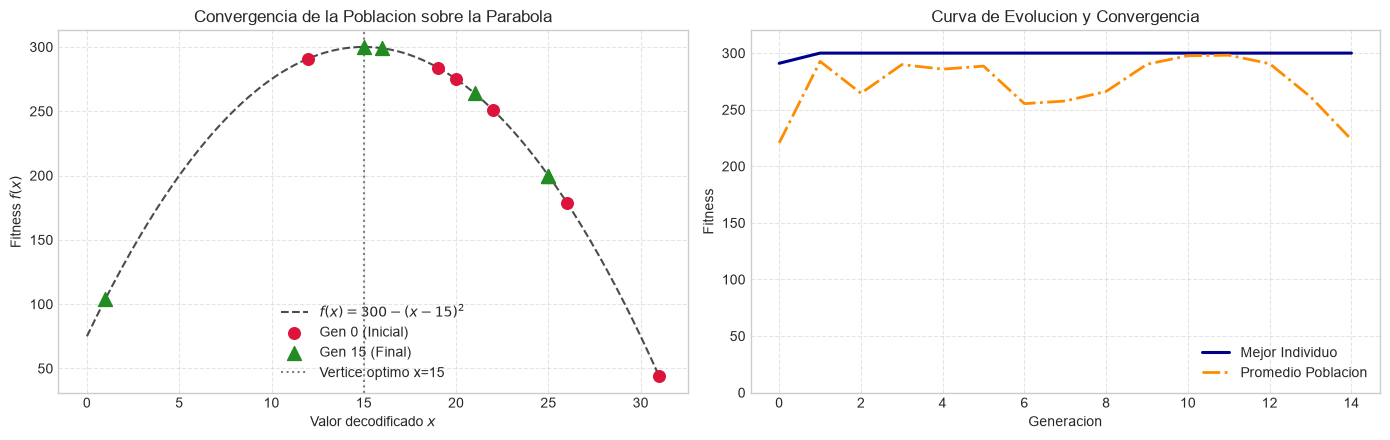

In [825]:
# Parametros de la simulacion genetica
rng = np.random.default_rng(42)
np.random.seed(42)

N_POBLACION = 6
N_GENES = 5
N_GENERACIONES = 15
PROB_MUTACION = 0.05
ELITE_COUNT = 2

# 1. Poblacion Inicial Aleatoria
poblacion = rng.integers(0, 2, size=(N_POBLACION, N_GENES))
poblacion_inicial = poblacion.copy()

historial_mejor_fit = []
historial_promedio_fit = []

for gen in range(N_GENERACIONES):
    x_vals = np.array([decodificar_cromosoma(ind) for ind in poblacion])
    fitness = np.array([calcular_fitness(x) for x in x_vals])
    
    historial_mejor_fit.append(np.max(fitness))
    historial_promedio_fit.append(np.mean(fitness))
    
    poblacion = nueva_generacion(poblacion, fitness, prob_mutacion=PROB_MUTACION, elite_count=ELITE_COUNT)

x_final = np.array([decodificar_cromosoma(ind) for ind in poblacion])
fit_final = np.array([calcular_fitness(x) for x in x_final])
idx_top = np.argmax(fit_final)
mejor_x = x_final[idx_top]
mejor_fit = fit_final[idx_top]

print(f"--- RESULTADOS FASE 1 ---")
print(f"Mejor solucion encontrada: x = {mejor_x} (Cromosoma: {poblacion[idx_top]})")
print(f"Fitness maximo alcanzado: f({mejor_x}) = {mejor_fit} (Optimo teorico = 300)\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Subplot 1: Parabola y Desplazamiento de los Individuos
x_curva = np.linspace(0, 31, 200)
y_curva = 300 - (x_curva - 15) ** 2
ax1.plot(x_curva, y_curva, color='black', linestyle='--', alpha=0.7, label=r'$f(x) = 300 - (x-15)^2$')
x_ini = np.array([decodificar_cromosoma(ind) for ind in poblacion_inicial])
ax1.scatter(x_ini, [calcular_fitness(x) for x in x_ini], color='crimson', s=70, label='Gen 0 (Inicial)', zorder=4)
ax1.scatter(x_final, fit_final, color='forestgreen', marker='^', s=100, label=f'Gen {N_GENERACIONES} (Final)', zorder=5)
ax1.axvline(15, color='gray', linestyle=':', label='Vertice optimo x=15')
ax1.set_title("Convergencia de la Poblacion sobre la Parabola")
ax1.set_xlabel("Valor decodificado $x$")
ax1.set_ylabel("Fitness $f(x)$")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Curva de Convergencia Generacional
ax2.plot(range(N_GENERACIONES), historial_mejor_fit, color='darkblue', linewidth=2.2, label='Mejor Individuo')
ax2.plot(range(N_GENERACIONES), historial_promedio_fit, color='darkorange', linestyle='-.', linewidth=2.0, label='Promedio Poblacion')
ax2.set_title("Curva de Evolucion y Convergencia")
ax2.set_xlabel("Generacion")
ax2.set_ylabel("Fitness")
ax2.set_ylim(0, 320)
ax2.legend(loc='lower right')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## FASE 2: Smart Rockets — "Rescate en el Cinturón de Asteroides" [OBLIGATORIA - 0.6 pts]
*(Optimización de Trayectorias Continuas con Física 2D y PyGAD)*

### Contexto de la Misión
Una nave de rescate quedó varada en el cuadrante inferior del espacio exterior y debe alcanzar la **Estación Espacial Orbital** ubicada en el extremo superior. Para lograrlo, debe atravesar un **campo denso de asteroides** con combustible limitado.

Cada individuo de la población es un **cohete autónomo** que posee un plan de propulsión codificado en su **ADN**:
- Cada gen es un vector de fuerza bidimensional $\vec{F}_t = (f_{x,t}, f_{y,t})$ aplicado en el instante de tiempo (frame) $t$.
- El tiempo de vida máximo de la misión es de `lifespan` frames.
- Dimensión del cromosoma: $2 \times \text{lifespan}$ genes continuos en $[-F_{\max}, F_{\max}]$.

### Física y Dinámica del Vuelo
En cada frame de la simulación:
1. $\vec{a}_t = \vec{F}_t$ (aceleración instantánea).
2. $\vec{v}_{t+1} = \vec{v}_t + \vec{a}_t$ (respetando una velocidad máxima $v_{\max}$).
3. $\vec{p}_{t+1} = \vec{p}_t + \vec{v}_{t+1}$ (actualización de posición).
4. **Detección de eventos:**
   - Si choca contra un asteroide o los límites de la arena: queda destruido (`crashed = True`) y se detiene.
   - Si ingresa al radio de acople de la estación: logra la misión (`reached = True`) y registra los frames empleados.

In [826]:
# ==========================================================================
# RECURSOS DADOS: Modelo Fisico 2D y Entorno Espacial
# ==========================================================================

# Coordenadas clave del escenario espacial (Arena 100 x 100)
START_POS = np.array([50.0, 8.0])
ESTACION_POS = np.array([50.0, 90.0])
RADIO_ESTACION = 5.0
LIFESPAN = 75       # Frames maximos de vida de cada cohete
MAX_FORCE = 0.7     # Magnitud maxima de propulsion por frame
MAX_SPEED = 2.5     # Velocidad terminal maxima

# Campo de asteroides circulares: array con filas [centro_x, centro_y, radio]
ASTEROIDES = np.array([
    [50.0, 48.0, 14.0],  # Gran asteroide central que bloquea la ruta directa
    [22.0, 68.0, 8.5],   # Asteroide lateral izquierdo
    [78.0, 68.0, 8.5],   # Asteroide lateral derecho
    [33.0, 28.0, 7.0],   # Asteroide de entrada inferior izquierdo
    [67.0, 28.0, 7.0]    # Asteroide de entrada inferior derecho
])

class Rocket:
    def __init__(self, dna, start_pos=START_POS, max_speed=MAX_SPEED):
        self.pos = np.array(start_pos, dtype=np.float64)
        self.vel = np.array([0.0, 0.0], dtype=np.float64)
        self.max_speed = max_speed
        self.dna = np.array(dna).reshape(-1, 2)  # Forma (lifespan, 2)
        self.crashed = False
        self.reached = False
        self.frames_usados = len(self.dna)
        self.trayectoria = [self.pos.copy()]
        
    def aplicar_fuerza(self, fuerza):
        self.vel += fuerza
        rapidez = np.linalg.norm(self.vel)
        if rapidez > self.max_speed:
            self.vel = (self.vel / rapidez) * self.max_speed
        self.pos += self.vel
        self.trayectoria.append(self.pos.copy())
        
    def verificar_colisiones(self, asteroides, estacion, radio_estacion=RADIO_ESTACION, arena_bounds=(0, 100, 0, 100)):
        xmin, xmax, ymin, ymax = arena_bounds
        if self.pos[0] < xmin or self.pos[0] > xmax or self.pos[1] < ymin or self.pos[1] > ymax:
            self.crashed = True
            return
            
        dist_est = np.linalg.norm(self.pos - estacion)
        if dist_est <= radio_estacion:
            self.reached = True
            return
            
        for ax, ay, ar in asteroides:
            if np.linalg.norm(self.pos - np.array([ax, ay])) <= ar:
                self.crashed = True
                return

def simular_cohete(dna, asteroides=ASTEROIDES, estacion=ESTACION_POS, radio_estacion=RADIO_ESTACION, lifespan=LIFESPAN, start_pos=START_POS):
    """
    Ejecuta el loop de simulacion temporal de un cohete a lo largo de su lifespan.
    """
    rocket = Rocket(dna, start_pos=start_pos)
    for frame in range(lifespan):
        if rocket.crashed or rocket.reached:
            rocket.frames_usados = frame
            break
        rocket.aplicar_fuerza(rocket.dna[frame])
        rocket.verificar_colisiones(asteroides, estacion, radio_estacion)
        
    dist_final = float(np.linalg.norm(rocket.pos - estacion))
    return {
        "dist_final": dist_final,
        "reached": rocket.reached,
        "crashed": rocket.crashed,
        "frames_usados": rocket.frames_usados,
        "trayectoria": np.array(rocket.trayectoria),
        "pos_final": rocket.pos.copy()
    }

### 2.2 [TODO 4] Diseño de la Función de Aptitud Multiobjetivo [0.6 pts]

El éxito evolutivo de la misión depende de cómo equilibremos tres factores en el **Fitness**:
1. **Cercanía al objetivo ($a$):** A menor distancia euclídea final ($d = \|\vec{p}_{final} - \vec{p}_{estacion}\|$), mayor debe ser el puntaje base (ej: $100 / (d + 1)$).
2. **Tiempo de llegada ($b$):** Si el cohete logró acoplar (`reached == True`), recibe una bonificación proporcional a los frames ahorrados $(\text{lifespan} - \text{frames\_usados})$.
3. **Penalización por colisión ($c$):** Si el cohete se estrelló (`crashed == True`), sufre un castigo severo multiplicando su puntaje por $0.1$.

**Consigna:** Programa `calcular_fitness_rocket` para soportar dos configuraciones de pesos:
- `"solo_cercania"`: Premia fuertemente la distancia final y el acople, pero **no** bonifica el tiempo invertido.
- `"velocidad"`: Además de cercanía y acople, otorga un **bono adicional** por cada frame ahorrado antes de agotar el `lifespan`.

In [827]:
# ==========================================================================
# [TODO 4] Funcion de Aptitud para Smart Rockets [0.6 pts]
# ==========================================================================

def calcular_fitness_rocket(dist_final, reached, crashed, frames_usados, lifespan, config="velocidad"):
    """
    TODO 4: Combina distancia final, acople exitoso, penalizacion de choque y tiempo.
    
    Parametros:
      dist_final: distancia euclidea final a la estacion (float >= 0).
      reached: booleano, True si acoplo en la estacion.
      crashed: booleano, True si colisiono contra un asteroide o pared.
      frames_usados: cantidad de frames transcurridos hasta detenerse (int).
      lifespan: tiempo total de simulacion disponible (int).
      config: 'solo_cercania' o 'velocidad'.
    Retorna:
      Valor escalar de fitness positivo (mayor valor = mejor cohete).
    """
    # ----------------------------------------------------------------------
    # Pista 1: fit_base = 100.0 / (dist_final + 1.0)
    # Pista 2: Si reached es True, agrega +300.0 de bonificacion.
    # Pista 3: En config == 'velocidad' y reached, suma (lifespan - frames_usados) * 8.0
    # Pista 4: Si crashed es True, castiga multiplicando el total por 0.1
    fit_base = 100.0 / (dist_final + 1.0)
    if reached:
      fit_base+=300
      if config=='velocidad':
         fit_base+=(lifespan-frames_usados)*8.0
    elif crashed:
      fit_base-=fit_base*0.1

    return fit_base
    # ----------------------------------------------------------------------

def fitness_smart_rockets(ga_instance, solution, solution_idx):
    """
    Wrapper compatible con PyGAD: simula el cohete y evalua su fitness.
    """
    res = simular_cohete(solution, ASTEROIDES, ESTACION_POS, RADIO_ESTACION, LIFESPAN, START_POS)
    return calcular_fitness_rocket(res["dist_final"], res["reached"], res["crashed"], res["frames_usados"], LIFESPAN, config="velocidad")


In [828]:
# TEST AUTOMATICO - TODO 4
fit_cerca = calcular_fitness_rocket(dist_final=2.0, reached=False, crashed=False, frames_usados=75, lifespan=75)
fit_lejos = calcular_fitness_rocket(dist_final=45.0, reached=False, crashed=False, frames_usados=75, lifespan=75)
fit_choco = calcular_fitness_rocket(dist_final=2.0, reached=False, crashed=True, frames_usados=40, lifespan=75)
fit_llego_rapido = calcular_fitness_rocket(dist_final=0.0, reached=True, crashed=False, frames_usados=25, lifespan=75, config="velocidad")
fit_llego_lento  = calcular_fitness_rocket(dist_final=0.0, reached=True, crashed=False, frames_usados=70, lifespan=75, config="velocidad")

assert fit_cerca is not None, "[ERROR] calcular_fitness_rocket retorno None. Completa la funcion en TODO 4."
assert fit_cerca > fit_lejos, "[ERROR] Mayor cercania debe otorgar mayor fitness."
assert fit_cerca > fit_choco, "[ERROR] Un cohete que choca debe recibir penalizacion frente a uno intacto a igual distancia."
assert fit_llego_rapido > fit_llego_lento, "[ERROR] En config='velocidad', llegar en menos frames debe dar mayor fitness."

f_sc_rapido = calcular_fitness_rocket(dist_final=0.0, reached=True, crashed=False, frames_usados=25, lifespan=75, config="solo_cercania")
f_sc_lento  = calcular_fitness_rocket(dist_final=0.0, reached=True, crashed=False, frames_usados=70, lifespan=75, config="solo_cercania")
assert np.isclose(f_sc_rapido, f_sc_lento), "[ERROR] En config='solo_cercania', los frames usados no deben alterar el fitness."
print("[OK] Felicitaciones: TODO 4 aprobado con exito. Funcion de aptitud de Smart Rockets validada.")

[OK] Felicitaciones: TODO 4 aprobado con exito. Funcion de aptitud de Smart Rockets validada.


### 2.3 Simulación Evolutiva con PyGAD
Configuramos por primera vez la librería `pygad.GA`.
Presta especial atención a los comentarios en el código que explican para qué sirve cada parámetro de la librería.

Iniciando mision de rescate Smart Rockets con PyGAD...
¡Evolucion completada!
Estado: ¡ACOPLE EXITOSO!
Distancia final: 3.00 px | Frames empleados: 52/75


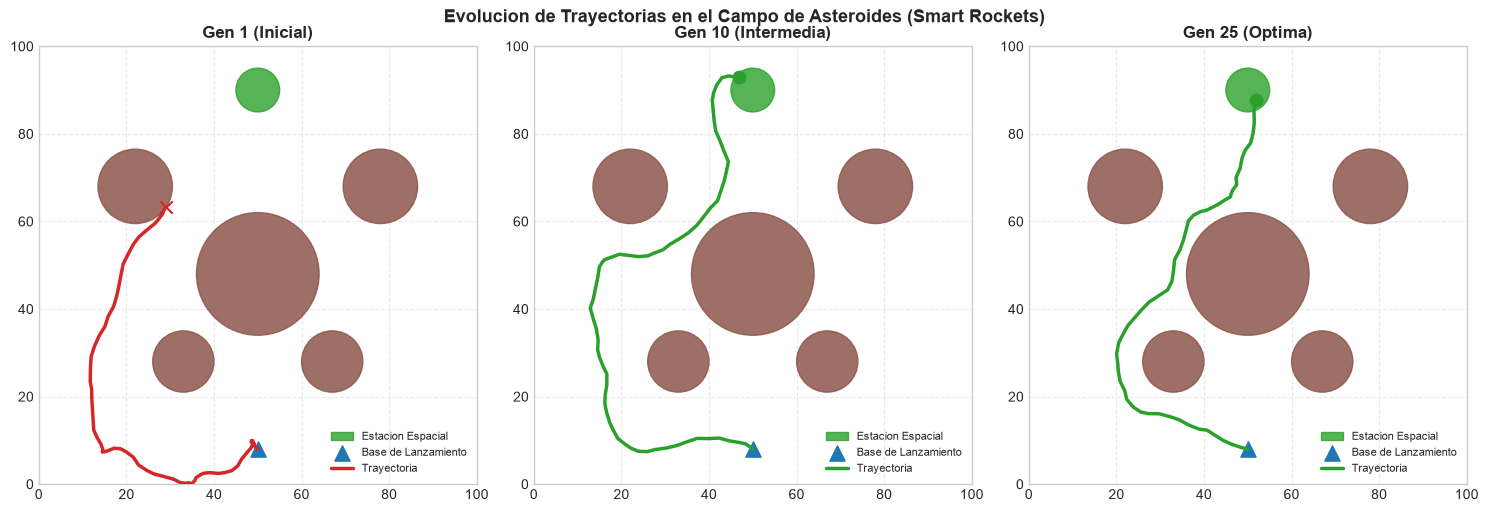

In [829]:
# Diccionario para capturar la evolucion en generaciones clave
historico_cohetes = {}

def callback_generacion_cohetes(ga):
    gen = ga.generations_completed
    if gen in [1, 10, 25]:
        sol, _, _ = ga.best_solution()
        historico_cohetes[gen] = simular_cohete(sol)

# ==============================================================================
# Configuracion de PyGAD para Optimizacion Continua de Fuerzas
# ==============================================================================
# Completa los parametros indicados con TODO para poner en marcha el optimizador:

ga_rockets = pygad.GA(
    # --- Parametros Generales del Ciclo Evolutivo ---
    num_generations=25,           # Cantidad de ciclos generacionales a simular
    num_parents_mating=8,         # Cantidad de progenitores seleccionados para cruce
    sol_per_pop=24,               # Tamano de la poblacion de cohetes por generacion
    keep_elitism=2,               # Individuos elite que pasan intactos a la siguiente generacion
    
    # --- Funcion de Evaluacion y Espacio del Cromosoma ---
    # TODO: Asigna la funcion wrapper de fitness que creaste en el bloque anterior
    fitness_func=fitness_smart_rockets,
    # TODO: Define la cantidad de genes (recuerda: 2 fuerzas continuas fx, fy por frame del LIFESPAN)
    num_genes=LIFESPAN * 2,
    # TODO: Rango continuo inicial de las fuerzas de propulsion (en funcion de MAX_FORCE)
    init_range_low=-MAX_FORCE,
    init_range_high=MAX_FORCE,
    
    # --- Operadores de Seleccion, Cruce y Mutacion Continua ---
    parent_selection_type="tournament", # Seleccion de padres por competencia en torneo
    K_tournament=3,                     # Cantidad de competidores en cada torneo
    crossover_type="uniform",           # Cruzamiento uniforme de genes continuos
    mutation_type="random",             # Mutacion aleatoria aditiva
    mutation_percent_genes=8,           # 8% de los genes mutan en cada descendiente
    random_mutation_min_val=-MAX_FORCE, # Magnitud minima de perturbacion de empuje
    random_mutation_max_val=MAX_FORCE,  # Magnitud maxima de perturbacion de empuje
    
    # --- Control y Telemetria ---
    on_generation=callback_generacion_cohetes, # Registra la mejor trayectoria por generacion
    random_seed=42
)

print("Iniciando mision de rescate Smart Rockets con PyGAD...")
ga_rockets.run()
mejor_sol, mejor_fit, _ = ga_rockets.best_solution()
res_final = simular_cohete(mejor_sol)
print(f"¡Evolucion completada!\nEstado: {'¡ACOPLE EXITOSO!' if res_final['reached'] else 'No llego'}")
print(f"Distancia final: {res_final['dist_final']:.2f} px | Frames empleados: {res_final['frames_usados']}/{LIFESPAN}")

# Visualizacion: Mapa de la mision espacial con trayectorias por generacion
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
gens_a_mostrar = [(1, "Gen 1 (Inicial)"), (10, "Gen 10 (Intermedia)"), (25, "Gen 25 (Optima)")]

for ax, (g, titulo) in zip(axes, gens_a_mostrar):
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect('equal')
    ax.set_title(titulo, fontweight='bold')
    
    for ax_x, ax_y, r in ASTEROIDES:
        circulo = plt.Circle((ax_x, ax_y), r, color='#8c564b', alpha=0.85, zorder=2)
        ax.add_patch(circulo)
        
    estacion_patch = plt.Circle(ESTACION_POS, RADIO_ESTACION, color='#2ca02c', alpha=0.8, zorder=3, label='Estacion Espacial')
    ax.add_patch(estacion_patch)
    ax.scatter(START_POS[0], START_POS[1], color='#1f77b4', marker='^', s=120, zorder=4, label='Base de Lanzamiento')
    
    datos_cohete = historico_cohetes.get(g, res_final)
    tray = datos_cohete["trayectoria"]
    color_linea = '#2ca02c' if datos_cohete['reached'] else ('#d62728' if datos_cohete['crashed'] else '#ff7f0e')
    ax.plot(tray[:, 0], tray[:, 1], color=color_linea, linewidth=2.5, zorder=5, label='Trayectoria')
    ax.scatter(tray[-1, 0], tray[-1, 1], color=color_linea, marker='x' if datos_cohete['crashed'] else 'o', s=80, zorder=6)
    
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Evolucion de Trayectorias en el Campo de Asteroides (Smart Rockets)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Animación Interactiva: La Evolución de Trayectorias en Acción
Para apreciar cómo aprendieron los cohetes, generamos una **animación interactiva frame a frame** comparando:
- 🔴 **Generación 1 (Inicial):** Cohete sin evolucionar que vuela en línea recta y se estrella contra el asteroide central.
- 🟠 **Generación 10 (Intermedia):** Cohete que aprende a torcer para esquivar el impacto directo pero aún no alcanza la meta con precisión.
- 🟢 **Generación 25 (Óptima):** Cohete evolucionado que rodea el cinturón con fluidez y acopla exitosamente en la estación orbital.

*Usa los controles del reproductor inferior (Play, Pausa, barra de avance y velocidad) para ver el vuelo en tiempo real:*

In [830]:
# ==========================================================================
# ANIMACION INTERACTIVA: Vuelo de Smart Rockets a traves del tiempo
# ==========================================================================
if 'historico_cohetes' not in locals() or len(historico_cohetes) == 0:
    print("⚠️ Por favor ejecuta primero la celda 2.3 para simular los cohetes.")
else:
    fig_anim, ax_anim = plt.subplots(figsize=(6.5, 6.5))
    ax_anim.set_xlim(0, 100)
    ax_anim.set_ylim(0, 100)
    ax_anim.set_aspect('equal')
    ax_anim.set_title("Animacion: Vuelo de Cohetes a Traves de las Generaciones", fontsize=11, fontweight='bold')

    # Dibujar Asteroides
    for ax_x, ax_y, r in ASTEROIDES:
        circulo = plt.Circle((ax_x, ax_y), r, color='#8c564b', alpha=0.85, zorder=2)
        ax_anim.add_patch(circulo)

    # Dibujar Estacion Espacial y Base
    estacion_patch = plt.Circle(ESTACION_POS, RADIO_ESTACION, color='#2ca02c', alpha=0.6, zorder=3)
    ax_anim.add_patch(estacion_patch)
    ax_anim.scatter(ESTACION_POS[0], ESTACION_POS[1], color='darkgreen', marker='*', s=140, zorder=4, label='Estacion')
    ax_anim.scatter(START_POS[0], START_POS[1], color='#1f77b4', marker='^', s=120, zorder=4, label='Base Lanzamiento')

    # Trayectorias de las 3 generaciones
    tray_g1 = historico_cohetes.get(1, res_final)["trayectoria"]
    tray_g10 = historico_cohetes.get(10, res_final)["trayectoria"]
    tray_g25 = historico_cohetes.get(25, res_final)["trayectoria"]

    line_g1, = ax_anim.plot([], [], color='#d62728', linestyle='--', linewidth=1.8, label='Gen 1 (Inicial)')
    head_g1, = ax_anim.plot([], [], marker='o', markersize=7, color='#d62728', zorder=6)

    line_g10, = ax_anim.plot([], [], color='#ff7f0e', linestyle='-.', linewidth=2.0, label='Gen 10 (Intermedia)')
    head_g10, = ax_anim.plot([], [], marker='o', markersize=7, color='#ff7f0e', zorder=6)

    line_g25, = ax_anim.plot([], [], color='#2ca02c', linewidth=2.5, label='Gen 25 (Optima)')
    head_g25, = ax_anim.plot([], [], marker='^', markersize=9, color='#2ca02c', zorder=7)

    texto_frame = ax_anim.text(3, 94, '', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax_anim.legend(loc='lower right', fontsize=8)
    ax_anim.grid(True, linestyle='--', alpha=0.4)

    def actualizar_frame(f):
        idx1 = min(f, len(tray_g1) - 1)
        line_g1.set_data(tray_g1[:idx1+1, 0], tray_g1[:idx1+1, 1])
        head_g1.set_data([tray_g1[idx1, 0]], [tray_g1[idx1, 1]])

        idx10 = min(f, len(tray_g10) - 1)
        line_g10.set_data(tray_g10[:idx10+1, 0], tray_g10[:idx10+1, 1])
        head_g10.set_data([tray_g10[idx10, 0]], [tray_g10[idx10, 1]])

        idx25 = min(f, len(tray_g25) - 1)
        line_g25.set_data(tray_g25[:idx25+1, 0], tray_g25[:idx25+1, 1])
        head_g25.set_data([tray_g25[idx25, 0]], [tray_g25[idx25, 1]])

        texto_frame.set_text(f"Frame {f+1}/{LIFESPAN}")
        return line_g1, head_g1, line_g10, head_g10, line_g25, head_g25, texto_frame

    anim_rockets = animation.FuncAnimation(
        fig_anim,
        actualizar_frame,
        frames=LIFESPAN,
        interval=45,
        blit=True
    )
    plt.close(fig_anim)
    display(HTML(anim_rockets.to_jshtml()))


### 2.5 Experimento Guiado: Exploración vs. Convergencia
Los algoritmos genéticos continuos son muy sensibles a dos parámetros:
1. `mutation_percent_genes`: Un valor muy bajo ($< 3\%$) estanca la población en trayectorias directas que chocan; un valor excesivo ($> 30\%$) destruye maniobras exitosas.
2. `lifespan` (Largo del ADN): Si es demasiado corto, es físicamente imposible llegar a la estación; si es demasiado largo, el espacio de búsqueda se infla innecesariamente.

> **Pregunta de reflexión:** ¿Por qué un cohete que choca temprano con `crashed = True` no debe seguir simulando el resto de los frames de su ADN?

Para ahorrar en términos de costo computacional, como sería en cálculos o simulación, y porque si siguiera moviendose el cohete no representaría un trayectoria valida, por lo que podría distorsionar valores como el fitness

## FASE 3: TSP — "La Ruta del Repartidor en Mar del Plata" [OBLIGATORIA - 0.6 pts]
*(Optimización de Permutaciones con Order Crossover y Swap Mutation en PyGAD)*

### Contexto del Problema
Una popular rotisería y pizzería ubicada en el centro de **Mar del Plata** (Peatonal San Martín) debe despachar pedidos a $N = 12$ puntos emblemáticos de la ciudad.
El cadete debe iniciar en el local, visitar cada uno de los clientes **exactamente una vez** y regresar al punto de partida, minimizando la distancia total recorrida para ahorrar combustible y tiempo.

### El Desafío de la Representación: Permutaciones
A diferencia de las fases anteriores, aquí los genes **no pueden repetirse ni omitirse**.
Un cromosoma es una permutación de los enteros $\{0, 1, \dots, N-1\}$:
$$\text{Ruta} = [c_0, c_1, c_2, \dots, c_{N-1}], \quad c_i \in \{0, \dots, N-1\}, \quad c_i \neq c_j$$

¿Qué ocurriría si usáramos un crossover tradicional de un punto?
- Padre 1: `[0, 1, 2, 3, 4]`
- Padre 2: `[4, 3, 2, 1, 0]`
- Cruce en $k=2$: Hijo = `[0, 1, 2, 1, 0]` $\implies$ ¡Ciudades 0 y 1 duplicadas, y ciudades 3 y 4 jamás visitadas!

Para resolver este problema introducimos dos operadores canónicos de orden:
1. **Order Crossover (OX):** Copia una subsecuencia contigua del Padre 1 y completa las ciudades restantes en el orden circular en que aparecen en el Padre 2, garantizando permutaciones 100% válidas.
2. **Swap Mutation:** Intercambia de posición dos ciudades elegidas al azar en el recorrido.

In [831]:
# ==========================================================================
# RECURSOS DADOS: Puntos de Entrega en Mar del Plata
# ==========================================================================

PUNTOS_MDP = {
    "Local Base (Peatonal)": np.array([50.0, 50.0]),
    "Playa Bristol":         np.array([55.0, 49.0]),
    "Casino Central":        np.array([53.5, 47.0]),
    "Torre Tanque":          np.array([47.0, 42.0]),
    "Plaza Colon":           np.array([52.0, 44.0]),
    "La Perla":              np.array([52.0, 58.0]),
    "Plaza Mitre":           np.array([46.0, 51.0]),
    "Cabo Corrientes":       np.array([56.0, 38.0]),
    "Playa Grande":          np.array([56.5, 31.0]),
    "Puerto MDP":            np.array([58.0, 21.0]),
    "Punta Mogotes":         np.array([54.0, 10.0]),
    "Parque Camet":          np.array([51.0, 74.0])
}

NOMBRES_CIUDADES = list(PUNTOS_MDP.keys())
COORD_CIUDADES = np.array(list(PUNTOS_MDP.values()))
NUM_CIUDADES = len(PUNTOS_MDP)

# Matriz de distancias euclideas precomputada: D[i, j] = distancia entre ciudad i y ciudad j
MATRIZ_DISTANCIAS = np.linalg.norm(COORD_CIUDADES[:, None, :] - COORD_CIUDADES[None, :, :], axis=-1)

print(f"Cargados {NUM_CIUDADES} puntos de entrega en Mar del Plata.")

Cargados 12 puntos de entrega en Mar del Plata.


In [832]:
# ==========================================================================
# RECURSOS DADOS: Operadores Custom de Permutacion para PyGAD
# ==========================================================================

def order_crossover(parents, offspring_size, ga_instance):
    """
    Order Crossover (OX): Preserva subsecuencias contiguas de un padre
    y rellena los elementos faltantes en el orden del segundo padre.
    """
    offspring = []
    idx = 0
    num_genes = offspring_size[1]
    while len(offspring) < offspring_size[0]:
        p1 = parents[idx % parents.shape[0]].copy()
        p2 = parents[(idx + 1) % parents.shape[0]].copy()
        
        corte1 = np.random.randint(0, num_genes - 1)
        corte2 = np.random.randint(corte1 + 1, num_genes)
        
        hijo = np.full(num_genes, -1, dtype=int)
        hijo[corte1:corte2] = p1[corte1:corte2]
        
        genes_en_hijo = set(hijo[corte1:corte2])
        genes_p2 = [g for g in np.roll(p2, -corte2) if g not in genes_en_hijo]
        
        posiciones = [(corte2 + i) % num_genes for i in range(len(genes_p2))]
        for pos, gen in zip(posiciones, genes_p2):
            hijo[pos] = gen
            
        offspring.append(hijo)
        idx += 1
    return np.array(offspring)

def swap_mutation(offspring, ga_instance):
    """
    Swap Mutation: Intercambia de posicion dos genes aleatorios en la permutacion.
    """
    num_genes = offspring.shape[1]
    for i in range(offspring.shape[0]):
        if np.random.rand() < 0.30:  # Probabilidad de mutar el recorrido
            i1, i2 = np.random.choice(num_genes, size=2, replace=False)
            offspring[i, i1], offspring[i, i2] = offspring[i, i2], offspring[i, i1]
    return offspring

### 3.2 [TODO 5] Función de Aptitud del Repartidor [0.6 pts]
Para un recorrido propuesto $\text{ruta} = [c_0, c_1, \dots, c_{N-1}]$, la distancia total es la suma de trayectos entre clientes consecutivos más el retorno a la base:
$$D_{\text{total}} = \sum_{i=0}^{N-2} \text{dist}(c_i, c_{i+1}) + \text{dist}(c_{N-1}, c_0)$$

Como `PyGAD` está diseñado para **maximizar**, no podemos devolver $D_{\text{total}}$ directamente (el algoritmo buscaría el camino más largo).
Debemos **invertir** la distancia:
$$\text{fitness} = \frac{1000.0}{D_{\text{total}} + 10^{-6}}$$
De este modo, a menor distancia recorrida, mayor será la aptitud obtenida.

In [833]:
# ==========================================================================
# [TODO 5] Funcion de Aptitud para el TSP en PyGAD [0.6 pts]
# ==========================================================================

def fitness_tsp(ga_instance, solution, solution_idx):
    """
    TODO 5: Calcula la distancia total del recorrido cíclico y retorna su inversa.
    
    Parametros:
      ga_instance: referencia a la instancia de PyGAD.
      solution: array 1D con la permutacion de indices de ciudades [c0, c1, ..., cN-1].
      solution_idx: indice del individuo.
    Retorna:
      Valor escalar de fitness (positivo, mayor = recorrido mas corto).
    """
    # ----------------------------------------------------------------------
    # Pista 1: Itera sumando MATRIZ_DISTANCIAS[origen, destino] para cada tramo i -> i+1.
    # Pista 2: ¡No olvides sumar el retorno de la ultima ciudad a la primera: (solution[-1] -> solution[0])!
    # Pista 3: Retorna float(1000.0 / (dist_total + 1e-6))
    dtot=sum(MATRIZ_DISTANCIAS[origen,destino] for origen,destino in zip(solution, np.roll(solution,-1)))
    fitness=1000.0/(dtot+10**(-6))
    return fitness
    # ----------------------------------------------------------------------


In [834]:
# TEST AUTOMATICO - TODO 5
ruta_test = np.arange(NUM_CIUDADES)
fit_test = fitness_tsp(None, ruta_test, 0)

assert fit_test is not None, "[ERROR] fitness_tsp retorno None. Completa la funcion en TODO 5."
assert fit_test > 0, "[ERROR] El fitness del TSP debe ser estrictamente positivo."

# Comparacion de rutas: un camino deliberadamente desordenado debe tener menor fitness
ruta_cruzada = np.array([0, 6, 1, 7, 2, 8, 3, 9, 4, 10, 5, 11])
fit_cruzada = fitness_tsp(None, ruta_cruzada, 1)

dist_directa = sum(MATRIZ_DISTANCIAS[ruta_test[i], ruta_test[(i+1)%NUM_CIUDADES]] for i in range(NUM_CIUDADES))
dist_cruzada = sum(MATRIZ_DISTANCIAS[ruta_cruzada[i], ruta_cruzada[(i+1)%NUM_CIUDADES]] for i in range(NUM_CIUDADES))

if dist_directa < dist_cruzada:
    assert fit_test > fit_cruzada, "[ERROR] El fitness debe ser mayor para el recorrido de menor distancia."
print("[OK] Felicitaciones: TODO 5 aprobado con exito. Funcion de aptitud del TSP validada.")

[OK] Felicitaciones: TODO 5 aprobado con exito. Funcion de aptitud del TSP validada.


### 3.3 Configuración de PyGAD para Permutaciones
Observa cómo configuramos `pygad.GA` para optimización combinatoria.
A diferencia de la Fase 2, aquí **no** usamos rangos de números reales continuos (`init_range`), sino una **población inicial de permutaciones** y nuestros **operadores custom**.

Optimizando recorrido de delivery en Mar del Plata...
Distancia minima encontrada: 136.38 km
Secuencia optima de visita:
  1. Plaza Colon
  2. Cabo Corrientes
  3. Playa Grande
  4. Puerto MDP
  5. Punta Mogotes
  6. Torre Tanque
  7. Local Base (Peatonal)
  8. Plaza Mitre
  9. Parque Camet
  10. La Perla
  11. Playa Bristol
  12. Casino Central
  -> Regreso a: Plaza Colon



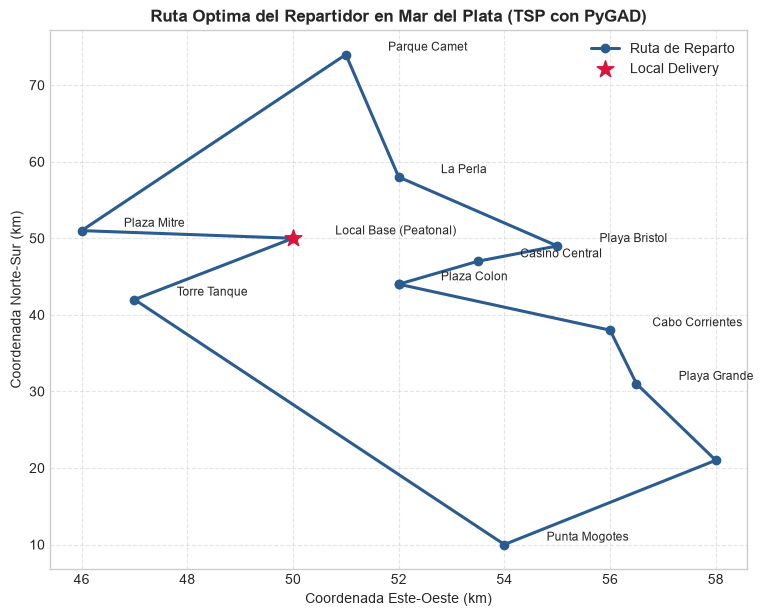

In [835]:
# Poblacion inicial: lista de 24 permutaciones aleatorias de las ciudades
poblacion_inicial_tsp = np.array([np.random.permutation(NUM_CIUDADES) for _ in range(24)])

# ==============================================================================
# Configuracion de PyGAD para el TSP
# ==============================================================================
# Completa los parametros indicados con TODO para conectar los operadores custom:

ga_tsp = pygad.GA(
    num_generations=50,
    num_parents_mating=8,
    keep_elitism=2,
    random_seed=42,
    gene_type=int,
    
    # --- [NUEVO] Poblacion Inicial y Evaluador de Permutacion ---
    # TODO: Conecta la funcion de fitness del TSP que programaste
    fitness_func=fitness_tsp,
    # TODO: Asigna la poblacion inicial personalizada de permutaciones (poblacion_inicial_tsp)
    initial_population=poblacion_inicial_tsp,
    
    # --- [NUEVO] Operadores Custom de Orden ---
    # TODO: Conecta el operador Order Crossover (order_crossover)
    crossover_type=order_crossover,
    # TODO: Conecta el operador de mutacion por intercambio (swap_mutation)
    mutation_type=swap_mutation
)

print("Optimizando recorrido de delivery en Mar del Plata...")
ga_tsp.run()

mejor_ruta, mejor_fit_tsp, _ = ga_tsp.best_solution()
mejor_ruta = [int(c) for c in mejor_ruta]
distancia_optima = sum(MATRIZ_DISTANCIAS[mejor_ruta[i], mejor_ruta[(i + 1) % NUM_CIUDADES]] for i in range(NUM_CIUDADES))

print(f"Distancia minima encontrada: {distancia_optima:.2f} km")
print("Secuencia optima de visita:")
for idx, c in enumerate(mejor_ruta):
    print(f"  {idx+1}. {NOMBRES_CIUDADES[c]}")
print(f"  -> Regreso a: {NOMBRES_CIUDADES[mejor_ruta[0]]}\n")

# Visualizacion del Mapa del Repartidor en Mar del Plata
plt.figure(figsize=(9, 7))
plt.title("Ruta Optima del Repartidor en Mar del Plata (TSP con PyGAD)", fontsize=12, fontweight='bold')

ruta_cerrada = mejor_ruta + [mejor_ruta[0]]
coords_ruta = COORD_CIUDADES[ruta_cerrada]
plt.plot(coords_ruta[:, 0], coords_ruta[:, 1], color='#2b5c8f', linewidth=2.2, linestyle='-', marker='o', label='Ruta de Reparto')

plt.scatter(COORD_CIUDADES[0, 0], COORD_CIUDADES[0, 1], color='crimson', s=160, marker='*', zorder=5, label='Local Delivery')
for i, nombre in enumerate(NOMBRES_CIUDADES):
    plt.annotate(f"{nombre}", (COORD_CIUDADES[i, 0] + 0.8, COORD_CIUDADES[i, 1] + 0.5), fontsize=8.5)

plt.xlabel("Coordenada Este-Oeste (km)")
plt.ylabel("Coordenada Norte-Sur (km)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 3.4 Experimentos de Reflexión sobre el TSP

#### A) Crecimiento Factorial del Espacio de Búsqueda
El número de recorridos posibles para $N$ ciudades es $(N-1)! / 2$:
- $N = 8 \implies 2.520$ rutas (resoluble por fuerza bruta en milisegundos).
- $N = 12 \implies 19.958.400$ rutas.
- $N = 16 \implies 6.53 \times 10^{11}$ rutas.
- $N = 20 \implies 6.08 \times 10^{16}$ rutas (¡requeriría años de cálculo exhaustivo!).

#### B) ¿Qué pasa si usamos el crossover por defecto de PyGAD?
Si ejecutamos PyGAD con `crossover_type="single_point"` sobre este problema, observaremos que los hijos resultantes tendrán **ciudades duplicadas y ciudades faltantes**.
Esto demuestra que un Algoritmo Genético no es una "caja negra": **la representación del cromosoma y los operadores genéticos deben respetar las invariantes del dominio**.

## FASE 4: Cifrado por Sustitución — "El Mensaje Interceptado" [BONUS TRACK - +0.5 pts]
*(Criptoanálisis Evolutivo con Operadores de Permutación y Fitness Lingüístico)*

### Contexto de la Misión
El equipo de inteligencia interceptó una comunicación secreta que contiene una revelación clasificada.
El mensaje fue codificado mediante un **cifrado por sustitución monoalfabética**:
- Cada letra del alfabeto `A-Z` fue reemplazada por otra según una clave secreta desconocida.
- **El texto original está oculto**: únicamente dispones del criptograma interceptado.
- Tu misión es descifrar el mensaje antes del amanecer utilizando un Algoritmo Genético.

### Espacio de Búsqueda Astronómico: $26!$
Una clave es una **permutación de las 26 letras del abecedario**:
$$26! \approx 4.03 \times 10^{26} \text{ combinaciones posibles}$$
Una supercomputadora evaluando mil millones de claves por segundo tardaría más de $12.000$ millones de años. La fuerza bruta es imposible.

### La Clave: Gradiente Lingüístico en Español
Para guiar al algoritmo sin estancarse, combinamos:
1. **Frecuencias de letras:** En español, `E` y `A` son las más frecuentes, mientras `K`, `W`, `X` son casi inexistentes.
2. **Similitud con Diccionario:** En lugar de exigir palabras 100% exactas desde el inicio, premiamos la **coincidencia parcial de letras** de las palabras descifradas frente a un vocabulario común del español. Así, cada letra bien deducida aumenta el fitness de forma continua.

In [836]:
# ==========================================================================
# RECURSOS DADOS: Herramientas de Cifrado y Mensaje Secreto Interceptado
# ==========================================================================

ALFABETO = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

def cifrar_mensaje(texto, clave_indices):
    """
    Cifra un texto sustituyendo cada letra segun la permutacion de indices de ALFABETO.
    """
    mapeo = {ALFABETO[i]: ALFABETO[clave_indices[i]] for i in range(26)}
    return "".join(mapeo.get(c, c) for c in texto.upper())

def descifrar_mensaje(texto_cifrado, clave_indices):
    """
    Descifra el texto aplicando la permutacion inversa de la clave candidata.
    """
    inversa = {ALFABETO[clave_indices[i]]: ALFABETO[i] for i in range(26)}
    return "".join(inversa.get(c, c) for c in texto_cifrado.upper())

# Tabla de frecuencias teoricas porcentuales de letras en el idioma espanol (%)
FREQ_ESPANOL = {
    'E': 13.68, 'A': 12.53, 'O': 8.68, 'S': 7.98, 'R': 6.87,
    'N': 6.71,  'I': 6.25,  'D': 5.86, 'L': 4.97, 'C': 4.68,
    'T': 4.63,  'U': 3.93,  'M': 3.15, 'P': 2.51, 'B': 1.42,
    'G': 1.01,  'V': 0.90,  'Y': 0.90, 'Q': 0.88, 'H': 0.70,
    'F': 0.69,  'Z': 0.52,  'J': 0.44, 'X': 0.22, 'W': 0.01, 'K': 0.01
}

# Diccionario de palabras frecuentes del espanol para orientar el fitness
PALABRAS_ESPANOL = [
    "EL", "LA", "DE", "EN", "QUE", "LOS", "DEL", "SE", "LAS", "POR", "UN", "PARA",
    "CON", "NO", "UNA", "SU", "AL", "LO", "COMO", "MAS", "PERO", "SUS", "LE", "YA",
    "FUE", "ESTE", "HA", "SI", "PORQUE", "ESTA", "SON", "ENTRE", "CUANDO", "MUY",
    "SIN", "SOBRE", "SER", "TIENE", "TAMBIEN", "ME", "HASTA", "HAY", "DONDE",
    "ES", "A", "FRACASAR", "INTENTAR"
]
SET_PALABRAS = set(PALABRAS_ESPANOL)

# Clave secreta real utilizada por el transmisor (permutacion de 26 elementos)
CLAVE_SECRETA_ENEMIGA = np.array([8, 16, 0, 24, 11, 9, 13, 1, 23, 5, 2, 12, 15, 3, 4, 21, 17, 22, 18, 25, 20, 7, 10, 14, 19, 6])

# MENSAJE INTERCEPTADO (CRIPTOGRAMA SECRETO)
# ¡El texto original no esta visible! Solo dispones de esta cadena cifrada:
MENSAJE_INTERCEPTADO = "JWIAISIW LS DE XDZLDZIW."

print("--- CRIPTOGRAMA INTERCEPTADO ---")
print(MENSAJE_INTERCEPTADO)


--- CRIPTOGRAMA INTERCEPTADO ---
JWIAISIW LS DE XDZLDZIW.


### 4.2 [TODO 6] Funciones de Aptitud Lingüística [+0.5 pts]

Para guiar al AG hacia la solución exacta, formulamos:

#### A) `fitness_frecuencias` (Distribución de Caracteres)
Mide qué tan cerca está la frecuencia de cada letra del texto descifrado respecto a la tabla teórica `FREQ_ESPANOL`:
$$\text{dist} = \sum_{L \in \text{ALFABETO}} |\text{freq}_{\text{obs}}(L) - \text{FREQ\_ESPANOL}[L]|, \quad \text{fitness} = \frac{100.0}{\text{dist} + 1.0}$$

#### B) `fitness_diccionario` (Reconocimiento y Similitud con Vocabulario)
Para cada palabra del texto descifrado:
- Si coincide **exactamente** con una palabra de `SET_PALABRAS`, suma un puntaje alto proporcional a su longitud (ej: `len(p) * 15.0`).
- Si no coincide exactamente, busca la palabra de igual longitud del diccionario con mayor cantidad de caracteres idénticos y suma `mejor_coincidencia * 2.0`.

In [837]:
# ==========================================================================
# [TODO 6] Funciones de Aptitud Criptografica [+0.5 pts Bonus]
# ==========================================================================

def coincidencia_letras(w1, w2):
    """Cuenta caracteres identicos en la misma posicion entre dos palabras de igual longitud."""
    if len(w1) != len(w2):
        return 0
    return sum(1 for c1, c2 in zip(w1, w2) if c1 == c2)

def fitness_frecuencias(ga_instance, solution, solution_idx):
    """
    TODO 6.A: Descifra el mensaje y calcula la distancia absoluta de frecuencias frente a FREQ_ESPANOL.
    Retorna 100.0 / (distancia + 1.0).
    """
    # ----------------------------------------------------------------------
    # Pista: suma abs(freq_observada(L) - FREQ_ESPANOL[L]) para cada letra L en ALFABETO.
    freq_observada = {L: 0.0 for L in ALFABETO}
    descifrado = descifrar_mensaje(MENSAJE_INTERCEPTADO, solution).upper()
    total_letras = sum(1 for c in descifrado if c in ALFABETO)
    if total_letras == 0:
        return 0.0
    for c in descifrado:
        if c in ALFABETO:
            freq_observada[c] += 100.0 / total_letras   
    ff=sum(abs(freq_observada[L]-FREQ_ESPANOL[L]) for L in ALFABETO)
    return 100.0/(ff+1.0)
    # ----------------------------------------------------------------------

def fitness_diccionario(ga_instance, solution, solution_idx):
    """
    TODO 6.B: Descifra el mensaje y suma puntos por palabras exactas o coincidencias de letras.
    """
    # ----------------------------------------------------------------------
    # Pista 1: Si la palabra p esta en SET_PALABRAS: suma len(p) * 25.0
    # Pista 2: Si no, busca la mejor coincidencia_letras(p, d) con palabras de igual longitud y suma mejor * 3.0
    cal=0.0
    mensaje_descifrado = descifrar_mensaje(MENSAJE_INTERCEPTADO, solution).upper()
    for s in mensaje_descifrado.split():
        p = s.strip(".,;:!?")
        if not p:
            continue
        if p in SET_PALABRAS:
            cal+=len(p)*25.0
        else:
            aux=[d for d in SET_PALABRAS if len(d) == len(p)]
            if aux:
                mejor=max(coincidencia_letras(p, d) for d in aux)
            else:
                mejor=0
            cal += mejor * 3.0
    return cal
    # ----------------------------------------------------------------------

def fitness_cripto_combinado(ga_instance, solution, solution_idx):
    """Funcion integradora que utiliza PyGAD."""
    return fitness_diccionario(ga_instance, solution, solution_idx)


In [838]:
# TEST AUTOMATICO - TODO 6 (BONUS TRACK)
clave_opuesta = (CLAVE_SECRETA_ENEMIGA + 13) % 26

fit_freq_optima = fitness_frecuencias(None, CLAVE_SECRETA_ENEMIGA, 0)
fit_freq_ruido  = fitness_frecuencias(None, clave_opuesta, 1)

assert fit_freq_optima is not None, "[ERROR] fitness_frecuencias retorno None. Completa TODO 6.A."
assert fit_freq_optima > fit_freq_ruido, "[ERROR] La clave real debe obtener mayor fitness de frecuencias que una clave invertida."

fit_dicc_optima = fitness_diccionario(None, CLAVE_SECRETA_ENEMIGA, 0)
fit_dicc_ruido  = fitness_diccionario(None, clave_opuesta, 1)

assert fit_dicc_optima is not None, "[ERROR] fitness_diccionario retorno None. Completa TODO 6.B."
assert fit_dicc_optima >= 450, f"[ERROR] La clave real debe obtener alto puntaje de diccionario, dio {fit_dicc_optima}."
assert fit_dicc_optima > fit_dicc_ruido, "[ERROR] La clave real debe reconocer sustancialmente mas vocabulario que una clave erronea."
print("[OK] ¡Felicitaciones! TODO 6 aprobado con exito. Bonus Track (+0.5 pts) asegurado.")

[OK] ¡Felicitaciones! TODO 6 aprobado con exito. Bonus Track (+0.5 pts) asegurado.


### 4.3 Ejecución del Criptoanálisis y Revelación del Mensaje
Configuramos PyGAD reutilizando los operadores de permutación de la Fase 3 (`order_crossover` y `swap_mutation`), con $160$ generaciones para explorar el espacio de $26!$ claves.
¡Al finalizar podrás leer qué mensaje secreto escondía la transmisión!

In [839]:
# Poblacion inicial: 70 permutaciones aleatorias de 26 letras
pob_inicial_cripto = np.array([np.random.permutation(26) for _ in range(70)])

# ==============================================================================
# Configuracion de PyGAD para Criptoanalisis de Sustitucion (26 letras)
# ==============================================================================
# Conecta los parametros correspondientes:

ga_cripto = pygad.GA(
    num_generations=160,                # Cantidad de generaciones aumentada para explorar 26!
    num_parents_mating=24,              # Progenitores seleccionados por generacion
    keep_elitism=3,                     # Preserva las 3 mejores claves en cada ciclo
    parent_selection_type="tournament",
    K_tournament=4,
    random_seed=42,
    gene_type=int,
    
    # --- [NUEVO] Fitness y Poblacion de Claves ---
    # TODO: Asigna la funcion de fitness combinada
    fitness_func=fitness_cripto_combinado,
    # TODO: Asigna la poblacion inicial de claves (pob_inicial_cripto)
    initial_population=pob_inicial_cripto,
    
    # --- Reutilizacion de Operadores de Permutacion de Fase 3 ---
    # TODO: Reutiliza el operador de cruce por orden (order_crossover)
    crossover_type=order_crossover,
    # TODO: Reutiliza el operador de mutacion por intercambio (swap_mutation)
    mutation_type=swap_mutation
)

print("Descifrando mensaje secreto interceptado con Algoritmos Geneticos (~8-10 seg)...")
ga_cripto.run()

mejor_clave, mejor_fit_c, _ = ga_cripto.best_solution()
mejor_clave = [int(x) for x in mejor_clave]
mensaje_revelado = descifrar_mensaje(MENSAJE_INTERCEPTADO, mejor_clave)
palabras_desc = sum(1 for p in re.findall(r'[A-Z]+', mensaje_revelado) if p in SET_PALABRAS)

print("\n" + "="*65)
print(" ¡MENSAJE DESCIFRADO POR EL ALGORITMO GENETICO!")
print("="*65)
print(f"Palabras del diccionario identificadas: {palabras_desc}")
print(f"Texto revelado:\n\"{mensaje_revelado}\"")
print("="*65)

Descifrando mensaje secreto interceptado con Algoritmos Geneticos (~8-10 seg)...

 ¡MENSAJE DESCIFRADO POR EL ALGORITMO GENETICO!
Palabras del diccionario identificadas: 4
Texto revelado:
"FRACASAR ES NO INTENTAR."


## Síntesis del Taller y Conclusiones

A lo largo de este taller has explorado las facetas clave de la computación evolutiva:
1. **Canónico artesanal (Fase 1 - Obligatoria):** Comprendiste el ciclo vital (selección por ruleta, cruce en un punto, mutación bit-flip y elitismo) sobre un espacio discreto de 5 bits.
2. **Espacio Continuo Multiobjetivo (Fase 2 - Obligatoria):** Guiaste un sistema físico continuo de 150 dimensiones equilibrando objetivos opuestos (cercanía, rapidez y evasión de obstáculos) y observaste su animación evolutiva frame a frame.
3. **Optimización de Permutaciones (Fase 3 - Obligatoria):** Descubriste por qué la representación importa y cómo operadores como *Order Crossover* y *Swap Mutation* resuelven problemas combinatorios complejos respetando restricciones estrictas.
4. **Criptoanálisis Lingüístico (Fase 4 - Bonus Track):** Fuiste testigo de cómo el AG extrae sentido de un espacio de $26! \approx 4 \times 10^{26}$ claves posibles guiándose por señales estadísticas del lenguaje humano.

---
## Cómo entregar tu trabajo
1. Asegúrate de que todas las celdas de autoevaluación (`assert`) hayan pasado con `[OK]`.
2. En tu terminal o consola ejecuta la suite completa de verificación:
   ```bash
   py test/test_taller_genetico.py
   ```
3. Realiza commit y push de tu rama y abre tu **Pull Request (PR)** hacia la rama principal.
4. El bot de evaluación automática ejecutará los tests en GitHub Actions y te dará tu puntaje final (2.0 pts base + 0.5 pts bonus).